Santiago Andrés Acosta Díaz

### Summary

In this notebook we will use `astropy` to read a .fits file and display its contents as an astronomical image.

---

## FITS files of images with different filters

En este caso, descargué datos de la nebulosa del águila Meisser 16.

---

## 1. Read the information from the .fits file

Now we will read the HDU information in the file, a list-like collection of HDU (Header Data Unit) objects.

In [80]:
from matplotlib import pyplot as plt
from astropy.io import fits
import numpy as np

# Hago esto porque me toca cambiar de imágenes mucho
arch_name = 'data/G005.877-0.418_24um.fits'
index = 0

# Cambio el nombre del archivo
with fits.open(arch_name) as hdul:
    hdul.info() 

Filename: data/G005.877-0.418_24um.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      14   (448, 249)   float64   


In [81]:
# En mi caso, la nebulosa que me interesa es "Eagle", entonces selecciono la 13
hdul[index].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  448                                                  
NAXIS2  =                  249                                                  
EXTEND  =                    T                                                  
CRVAL1  =                  0.0                                                  
CRVAL2  =                 -0.0                                                  
CRPIX1  =              10458.0                                                  
CRPIX2  =               -467.0                                                  
CDELT1  =         -0.001666667                                                  
CDELT2  =          0.001666667                                                  
CTYPE1  = 'GLON-CAR'        

Now we read the data and assign it to an object in Python,

In [82]:
hdul = fits.open(arch_name)
image_data = hdul[index].data
hdul.close()

image_data.shape

(249, 448)

## 2. Image Display

When visualizing with a gray color mada one has

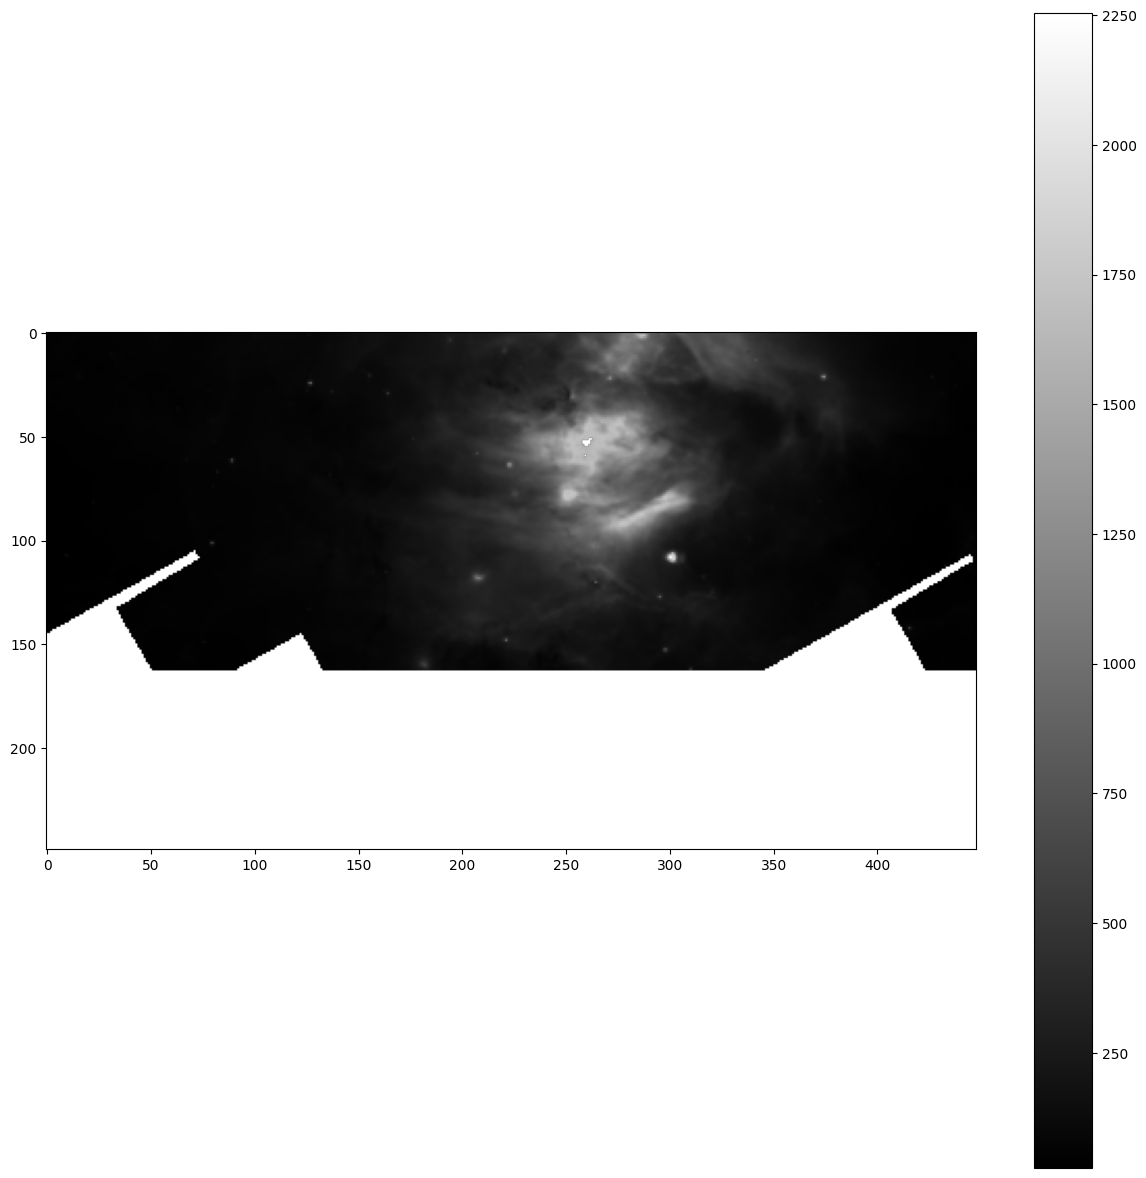

In [83]:
plt.figure(figsize=(15,15))
plt.imshow(image_data, cmap='gray')
plt.colorbar()
plt.show()

The image is almost completely dark. Changing the color map does not give a better result,

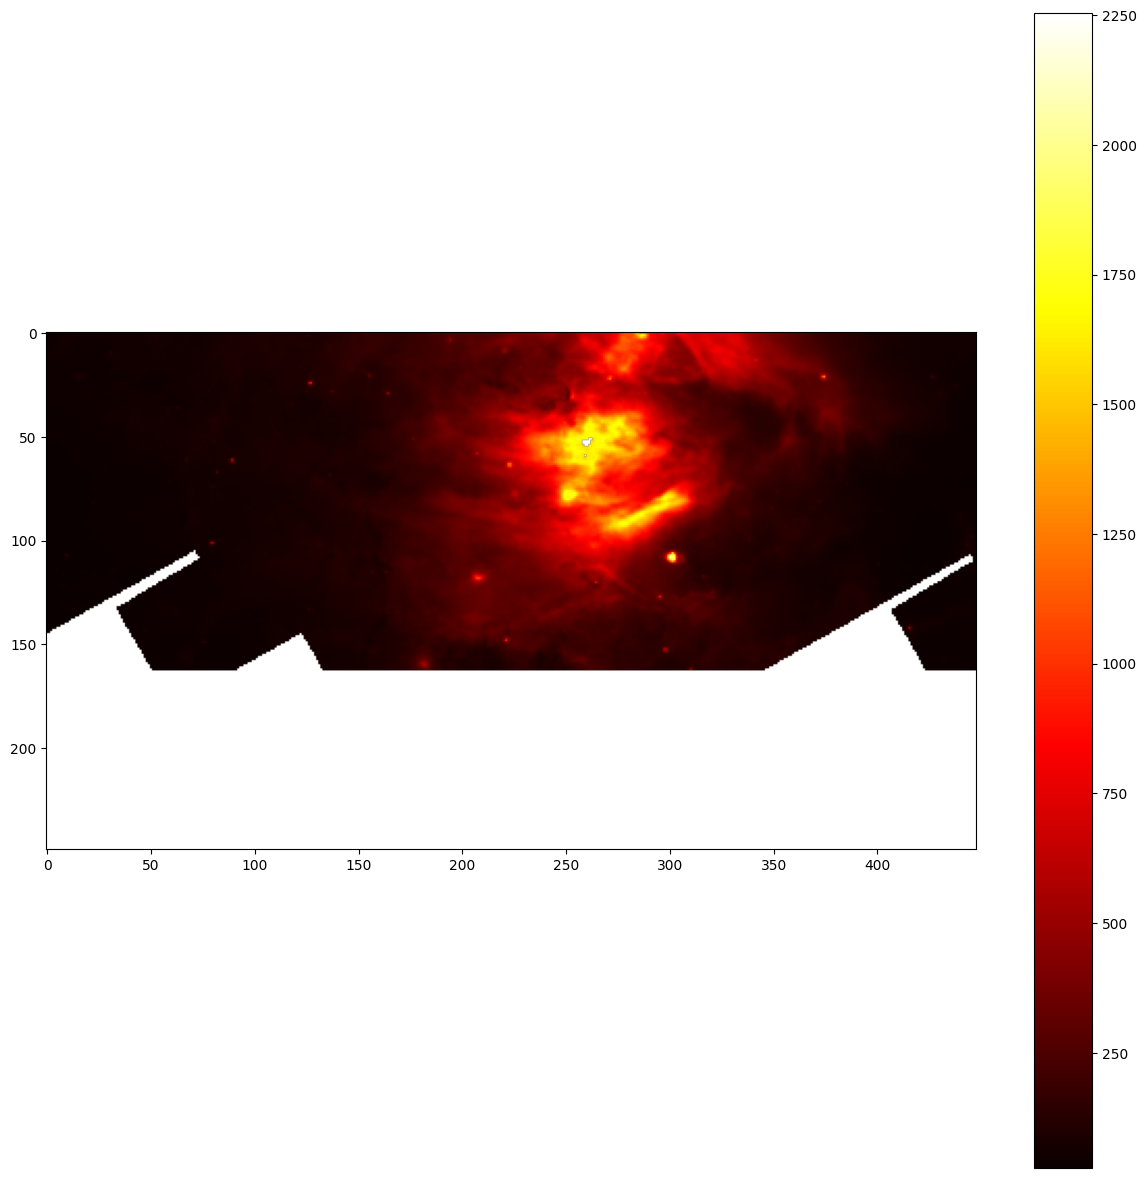

In [84]:
plt.figure(figsize=(15,15))
plt.imshow(image_data, cmap='hot')
plt.colorbar()
plt.show()

These results are due to the wide range of values that the numbers take within the array. To improve the image we will use a logarithmic scale,

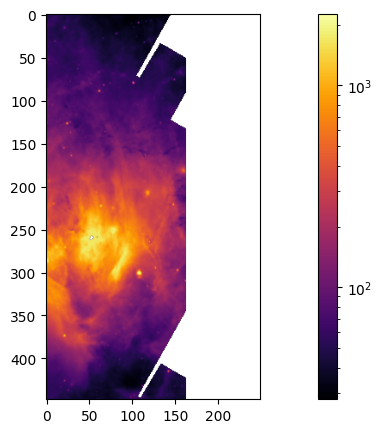

In [85]:
from matplotlib.colors import LogNorm
plt.figure(figsize=(15,5))
plt.imshow(image_data.T, cmap='inferno', norm=LogNorm())
plt.colorbar()
plt.show()

There seems to be a lot of noise. In order to understand this behavior, let us analyize the data. First, note that the set includes negative values,

In [86]:
image_data

array([[51.140389  , 51.63538226, 51.29639318, ..., 56.36238029,
        56.11675844, 55.73706038],
       [51.07885495, 51.82185544, 50.80446423, ..., 56.52261375,
        55.85286832, 55.42933493],
       [50.57690103, 51.31832378, 50.62352331, ..., 55.295435  ,
        55.35117906, 55.15569648],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]], shape=(249, 448), dtype='>f8')

The minimum value is

In [90]:
# Aquí modifico porque mi imagen tiene muchos nan, 
np.nanmin(image_data)

np.float64(27.8431647219731)

Now we will modify the data using this value and plot

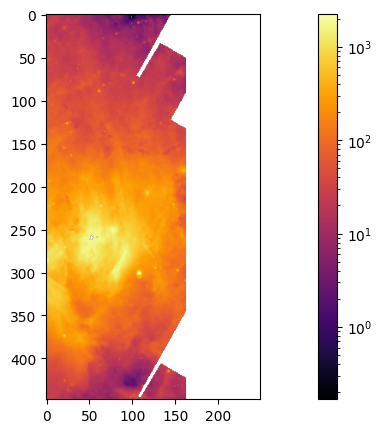

In [91]:
image_data2 = image_data - np.nanmin(image_data)

from matplotlib.colors import LogNorm
plt.figure(figsize=(15,5))
plt.imshow(image_data2.T, cmap='inferno', norm=LogNorm())
plt.colorbar()
plt.show()